# Stock Market Portfolio Risk & Volatility Analysis

**Texas A&M University | 2026**

## Project Overview

This project analyzes the risk and performance characteristics of an equal-weight portfolio consisting of 20 selected large-cap U.S. equities over approximately three years of daily market data.

Using Python, the analysis evaluates portfolio performance, volatility, downside risk, market sensitivity, and individual stock contributions to portfolio risk. Statistical methods include historical Value at Risk (VaR), Expected Shortfall, Sharpe ratios, rolling volatility, maximum drawdown, correlation analysis, and ordinary least squares (OLS) regression for estimating market Beta.

The analysis uses the S&P 500 Index as the market benchmark and examines how diversification affects portfolio-level risk relative to the individual securities in the sample.

### Key Questions

- How did the portfolio perform over the sample period?
- How does portfolio volatility compare with individual stock volatility?
- What proportion of portfolio risk is associated with each stock?
- How large were historical downside losses?
- How sensitive was the portfolio to movements in the S&P 500?
- How do individual stocks differ in their risk-return characteristics?

### Tools

- Python
- pandas
- NumPy
- yfinance
- matplotlib
- seaborn
- statsmodels
- scikit-learn

## Methodology

### Data

Daily adjusted market prices were retrieved using `yfinance` for 20 selected large-cap U.S. equities and the S&P 500 Index (`^GSPC`) over approximately three years.

The analysis period runs from September 2023 through September 2026 and contains 753 daily return observations.

### Portfolio Construction

The portfolio uses equal weights across all 20 stocks:

- 5% allocation to each stock
- 100% total portfolio allocation
- Daily portfolio returns calculated as the weighted sum of individual stock returns

This construction effectively represents a portfolio that is rebalanced to equal weights each trading day.

### Return & Performance Analysis

Daily percentage returns were calculated from adjusted market prices. Portfolio performance was evaluated using:

- Cumulative return
- Geometrically annualized return
- Annualized volatility
- Sharpe ratio
- Maximum drawdown

### Risk Analysis

Portfolio downside risk was evaluated using historical:

- 95% Value at Risk (VaR)
- 95% Expected Shortfall (ES)
- 30-day rolling annualized volatility

Risk contribution was calculated from the portfolio covariance matrix to determine each stock's percentage contribution to total portfolio variance.

### Market Sensitivity

Ordinary least squares regression was used to estimate portfolio and individual-stock Beta relative to the S&P 500.

The portfolio regression takes the form:

`Portfolio Return = α + β(S&P 500 Return) + ε`

HC3 heteroskedasticity-robust standard errors were used when evaluating regression inference.

### Risk-Free Rate Assumption

A 4% annual risk-free rate was assumed for Sharpe ratio calculations. The annual rate was converted to an equivalent daily rate using 252 trading days per year.

### Annualization

Daily volatility and Sharpe ratios were annualized using 252 trading days per year. Annualized returns were calculated using the exact calendar length of the sample period.

In [260]:
# Stock Market Portfolio Risk & Volatility Analysis
# Texas A&M University | 2026
#importing everything I need here

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression

print("Environment ready.")

Environment ready.


In [261]:

# just kind of setting up the stock names and running a basic diagnostic
tickers = [
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL",
    "META", "JPM", "V", "MA", "JNJ",
    "PFE", "XOM", "CVX", "WMT", "COST",
    "KO", "PG", "CAT", "BA", "UNH"
]

benchmark = "^GSPC"

print(f"Stocks: {len(tickers)}")
print(f"Benchmark: {benchmark}")

Stocks: 20
Benchmark: ^GSPC


In [262]:
# just loading in my data here and again testing diagnostics

prices = yf.download(
    tickers + [benchmark],
    period="3y",
    auto_adjust=True
)

print(prices.head())
print(f"\nRows: {prices.shape[0]}")
print(f"Columns: {prices.shape[1]}")

[*********************100%***********************]  21 of 21 completed

Price            Close                                                  \
Ticker            AAPL        AMZN          BA         CAT        COST   
Date                                                                     
2023-09-19  176.680405  137.630005  204.479996  268.128021  542.356567   
2023-09-20  173.148163  135.289993  202.369995  267.111664  541.856873   
2023-09-21  171.608963  129.330002  199.949997  260.803253  533.447876   
2023-09-22  172.457489  129.119995  197.710007  261.790771  536.821167   
2023-09-25  173.730270  131.270004  198.779999  262.950775  536.849915   

Price                                                                  ...  \
Ticker             CVX       GOOGL         JNJ         JPM         KO  ...   
Date                                                                   ...   
2023-09-19  147.485184  136.738831  148.945068  139.418167  53.368050  ...   
2023-09-20  147.035309  132.479355  149.597061  138.828400  53.606541  ...   
2023-09-21  145.7

In [263]:
# closing prices yay
close_prices = prices["Close"].copy()

print(close_prices.head())
print(f"\nShape: {close_prices.shape}")
print("\nMissing values:")
print(close_prices.isna().sum())

Ticker            AAPL        AMZN          BA         CAT        COST  \
Date                                                                     
2023-09-19  176.680405  137.630005  204.479996  268.128021  542.356567   
2023-09-20  173.148163  135.289993  202.369995  267.111664  541.856873   
2023-09-21  171.608963  129.330002  199.949997  260.803253  533.447876   
2023-09-22  172.457489  129.119995  197.710007  261.790771  536.821167   
2023-09-25  173.730270  131.270004  198.779999  262.950775  536.849915   

Ticker             CVX       GOOGL         JNJ         JPM         KO  ...  \
Date                                                                   ...   
2023-09-19  147.485184  136.738831  148.945068  139.418167  53.368050  ...   
2023-09-20  147.035309  132.479355  149.597061  138.828400  53.606541  ...   
2023-09-21  145.712204  129.210464  148.449249  137.742508  52.780979  ...   
2023-09-22  146.673660  129.022263  147.384018  136.422562  52.836018  ...   
2023-09-25  1

In [264]:
# returns calculations :)
returns = close_prices.pct_change().dropna()

print(returns.head())
print(f"\nShape: {returns.shape}")
print("\nMissing values:")
print(returns.isna().sum())

Ticker          AAPL      AMZN        BA       CAT      COST       CVX  \
Date                                                                     
2023-09-20 -0.019992 -0.017002 -0.010319 -0.003791 -0.000921 -0.003050   
2023-09-21 -0.008889 -0.044053 -0.011958 -0.023617 -0.015519 -0.008999   
2023-09-22  0.004945 -0.001624 -0.011203  0.003786  0.006324  0.006598   
2023-09-25  0.007380  0.016651  0.005412  0.004431  0.000054  0.014614   
2023-09-26 -0.023398 -0.040299 -0.015796 -0.017318 -0.010132 -0.005394   

Ticker         GOOGL       JNJ       JPM        KO  ...      META      MSFT  \
Date                                                ...                       
2023-09-20 -0.031150  0.004377 -0.004230  0.004469  ... -0.017701 -0.023977   
2023-09-21 -0.024675 -0.007673 -0.007822 -0.015400  ... -0.013148 -0.003866   
2023-09-22 -0.001457 -0.007176 -0.009583  0.001043  ...  0.011328 -0.007886   
2023-09-25  0.006603 -0.001496  0.004941 -0.010417  ...  0.005851  0.001672   
2023-09

In [265]:
# Here I assign each stock their weight in the portfolio.
weights = np.repeat(1 / len(tickers), len(tickers))

portfolio_returns = returns[tickers].mul(weights).sum(axis=1)

print(portfolio_returns.head())
print(f"\nNumber of observations: {len(portfolio_returns)}")
print(f"Portfolio weight per stock: {weights[0]:.2%}")
print(f"Total portfolio weight: {weights.sum():.2%}")

Date
2023-09-20   -0.007977
2023-09-21   -0.014659
2023-09-22    0.000292
2023-09-25    0.004524
2023-09-26   -0.013006
dtype: float64

Number of observations: 752
Portfolio weight per stock: 5.00%
Total portfolio weight: 100.00%


In [266]:
# Volatility Calculations for Entire Portfolio
daily_volatility = portfolio_returns.std()
annualized_volatility = daily_volatility * np.sqrt(252)

print(f"Daily volatility: {daily_volatility:.4%}")
print(f"Annualized volatility: {annualized_volatility:.2%}")

Daily volatility: 0.7922%
Annualized volatility: 12.58%


In [267]:
# Individual stock volatility

stock_volatility = returns[tickers].std() * np.sqrt(252)

print(stock_volatility.sort_values(ascending=False))

Ticker
NVDA     0.469169
META     0.376251
UNH      0.368212
BA       0.346148
CAT      0.324864
AMZN     0.322929
GOOGL    0.306839
AAPL     0.268309
MSFT     0.262371
PFE      0.243844
XOM      0.234803
CVX      0.231342
WMT      0.230497
JPM      0.230430
MA       0.204595
COST     0.203733
V        0.202415
JNJ      0.179503
PG       0.178536
KO       0.165756
dtype: float64


In [268]:
# Correlation Matrix Creation

correlation_matrix = returns[tickers].corr()

print(correlation_matrix.round(2))

Ticker  AAPL  MSFT  NVDA  AMZN  GOOGL  META   JPM     V    MA   JNJ   PFE  \
Ticker                                                                      
AAPL    1.00  0.35  0.30  0.37   0.36  0.33  0.28  0.34  0.35  0.06  0.20   
MSFT    0.35  1.00  0.42  0.53   0.36  0.42  0.23  0.29  0.34 -0.16  0.06   
NVDA    0.30  0.42  1.00  0.44   0.37  0.43  0.25  0.13  0.15 -0.26 -0.04   
AMZN    0.37  0.53  0.44  1.00   0.57  0.57  0.32  0.30  0.33 -0.13  0.08   
GOOGL   0.36  0.36  0.37  0.57   1.00  0.41  0.25  0.22  0.21 -0.06  0.06   
META    0.33  0.42  0.43  0.57   0.41  1.00  0.27  0.28  0.32 -0.14  0.04   
JPM     0.28  0.23  0.25  0.32   0.25  0.27  1.00  0.44  0.43  0.12  0.18   
V       0.34  0.29  0.13  0.30   0.22  0.28  0.44  1.00  0.86  0.21  0.21   
MA      0.35  0.34  0.15  0.33   0.21  0.32  0.43  0.86  1.00  0.19  0.21   
JNJ     0.06 -0.16 -0.26 -0.13  -0.06 -0.14  0.12  0.21  0.19  1.00  0.41   
PFE     0.20  0.06 -0.04  0.08   0.06  0.04  0.18  0.21  0.21  0.41  1.00   

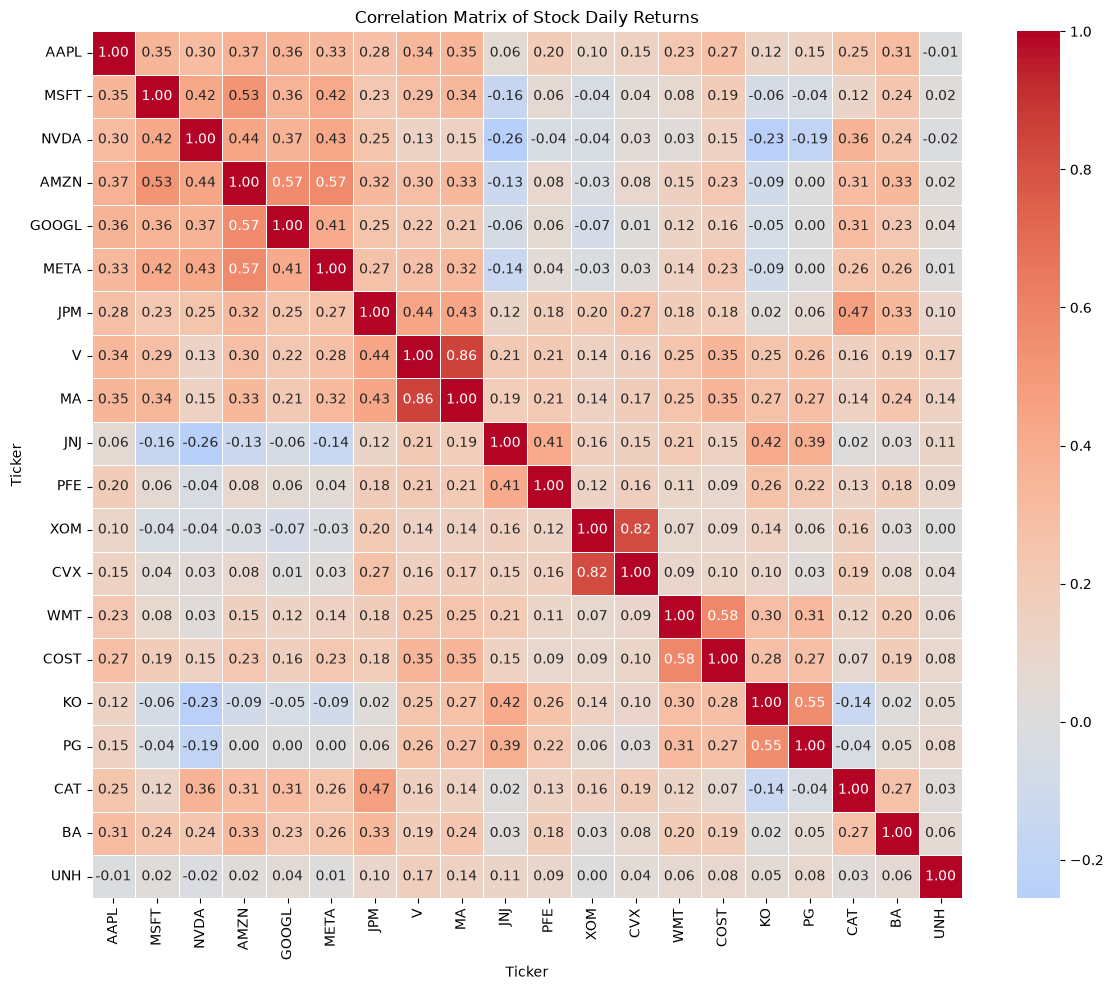

In [269]:
#Stock Return Correlation Heatmap

plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Stock Daily Returns")
plt.tight_layout()

plt.show()

In [270]:
# cumulative return

cumulative_portfolio_return = (1 + portfolio_returns).prod() - 1

print(f"3-year cumulative portfolio return: {cumulative_portfolio_return:.2%}")

3-year cumulative portfolio return: 87.44%


In [271]:
# annulizing the return

annualized_return = (1 + cumulative_portfolio_return) ** (1 / 3) - 1

print(f"Annualized portfolio return: {annualized_return:.2%}")

Annualized portfolio return: 23.30%


In [272]:
# this essentially tells us the answer to "Based on the historical distribution of our portfolio's daily returns, how bad is a loss on a typical worst-5%-of-days threshold?"

historical_var_95 = -np.percentile(portfolio_returns, 5)

print(f"Historical 95% 1-day VaR: {historical_var_95:.2%}")

Historical 95% 1-day VaR: 1.11%


In [273]:
# this will identify periods of HIGH volitility

rolling_volatility = portfolio_returns.rolling(window=30).std() * np.sqrt(252)

print(rolling_volatility.dropna().head())
print(f"\nAverage 30-day rolling volatility: {rolling_volatility.mean():.2%}")
print(f"Maximum 30-day rolling volatility: {rolling_volatility.max():.2%}")
print(f"Minimum 30-day rolling volatility: {rolling_volatility.min():.2%}")

Date
2023-10-31    0.124629
2023-11-01    0.128181
2023-11-02    0.128604
2023-11-03    0.129569
2023-11-06    0.129170
dtype: float64

Average 30-day rolling volatility: 11.34%
Maximum 30-day rolling volatility: 37.79%
Minimum 30-day rolling volatility: 5.65%


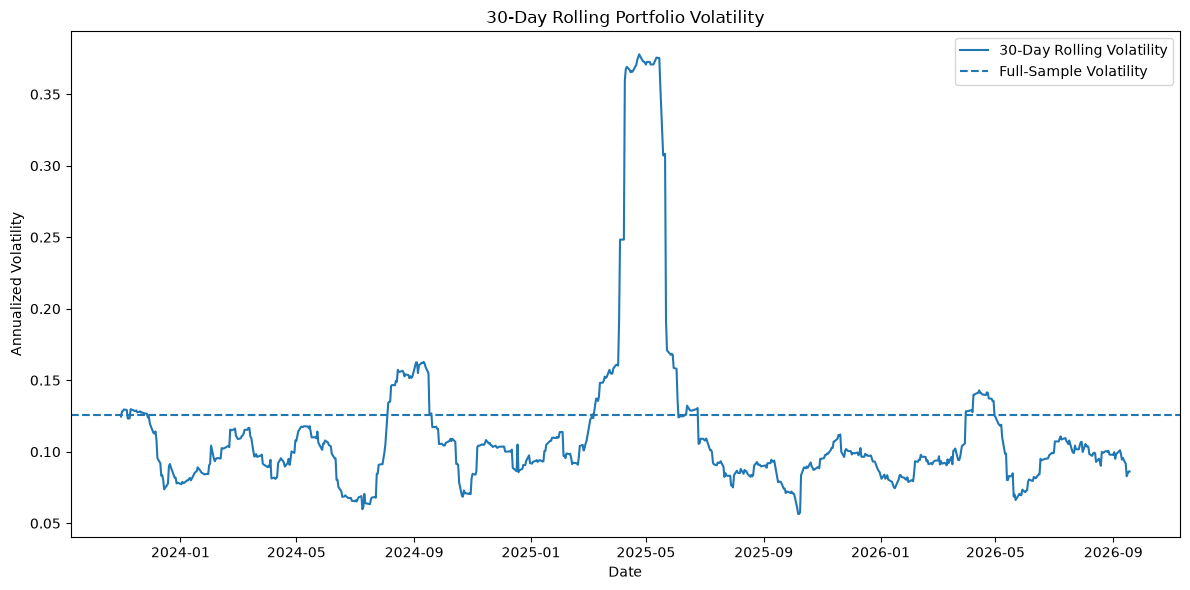

In [274]:
# Volatility Over Time Graph

plt.figure(figsize=(12, 6))

plt.plot(
    rolling_volatility.index,
    rolling_volatility,
    label="30-Day Rolling Volatility"
)

plt.axhline(
    annualized_volatility,
    linestyle="--",
    label="Full-Sample Volatility"
)

plt.title("30-Day Rolling Portfolio Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.tight_layout()

plt.show()

In [275]:
# This is to tell me what the exact date of the spike is on the graph here. most likely from the trump tarrifs in '25.

max_vol_date = rolling_volatility.idxmax()
max_vol_value = rolling_volatility.max()

print(f"Peak rolling volatility: {max_vol_value:.2%}")
print(f"Peak volatility date: {max_vol_date.date()}")

Peak rolling volatility: 37.79%
Peak volatility date: 2025-04-24


In [276]:
# probing some more data

event_window = portfolio_returns.loc["2025-04-01":"2025-05-15"]

print(event_window.sort_values().head(10))

Date
2025-04-04   -0.058080
2025-04-03   -0.038890
2025-04-10   -0.028413
2025-04-21   -0.023169
2025-04-16   -0.016061
2025-04-08   -0.010941
2025-05-06   -0.006905
2025-04-15   -0.005286
2025-05-05   -0.004751
2025-05-13   -0.004361
dtype: float64


In [277]:
# testing my portfolio against the S&P 500
market_returns = returns[benchmark]

comparison = pd.concat(
    [portfolio_returns, market_returns],
    axis=1
)

comparison.columns = ["Portfolio", "S&P 500"]

print(comparison.head())
print(f"\nCorrelation with S&P 500: {comparison['Portfolio'].corr(comparison['S&P 500']):.3f}")

            Portfolio   S&P 500
Date                           
2023-09-20  -0.007977 -0.009395
2023-09-21  -0.014659 -0.016401
2023-09-22   0.000292 -0.002296
2023-09-25   0.004524  0.004023
2023-09-26  -0.013006 -0.014735

Correlation with S&P 500: 0.896


In [278]:
#Robust OLS Regression for Portfolio Beta

X = sm.add_constant(market_returns)
y = portfolio_returns

robust_model = sm.OLS(y, X).fit(cov_type="HC3")

print(robust_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.803
Model:                            OLS   Adj. R-squared:                  0.803
Method:                 Least Squares   F-statistic:                     691.6
Date:                Fri, 18 Sep 2026   Prob (F-statistic):          1.60e-108
Time:                        15:02:41   Log-Likelihood:                 3183.1
No. Observations:                 752   AIC:                            -6362.
Df Residuals:                     750   BIC:                            -6353.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.000      2.233      0.0

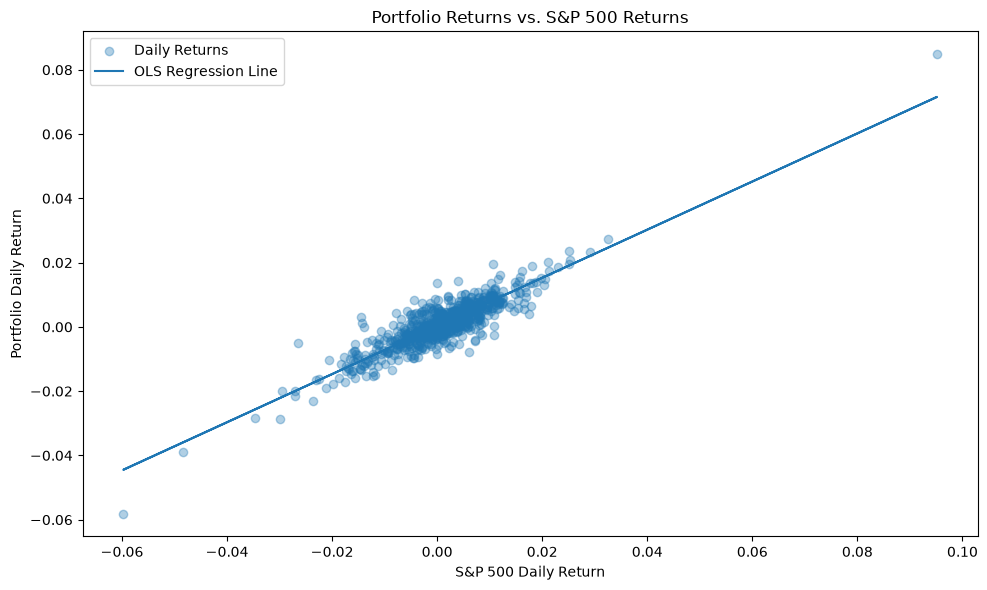

In [279]:
#plotting my portfolio against the S&P
plt.figure(figsize=(10, 6))

plt.scatter(
    market_returns,
    portfolio_returns,
    alpha=0.35,
    label="Daily Returns"
)

plt.plot(
    market_returns,
    robust_model.predict(X),
    label="OLS Regression Line"

)

plt.title("Portfolio Returns vs. S&P 500 Returns")
plt.xlabel("S&P 500 Daily Return")
plt.ylabel("Portfolio Daily Return")
plt.legend()
plt.tight_layout()

plt.show()

In [280]:
#plotting again 

X_sklearn = market_returns.to_numpy().reshape(-1, 1)
y_sklearn = portfolio_returns.to_numpy()

sklearn_model = LinearRegression()
sklearn_model.fit(X_sklearn, y_sklearn)

beta_sklearn = sklearn_model.coef_[0]
alpha_sklearn = sklearn_model.intercept_
r_squared_sklearn = sklearn_model.score(X_sklearn, y_sklearn)

print(f"Alpha: {alpha_sklearn:.6f}")
print(f"Beta: {beta_sklearn:.4f}")
print(f"R-squared: {r_squared_sklearn:.4f}")

Alpha: 0.000292
Beta: 0.7490
R-squared: 0.8033


In [281]:
# plotting each individual stock against the S&P

stock_betas = {}

for ticker in tickers:
    stock_model = sm.OLS(
        returns[ticker],
        sm.add_constant(market_returns)
    ).fit()

    stock_betas[ticker] = stock_model.params[benchmark]

stock_betas = pd.Series(stock_betas).sort_values(ascending=False)

print(stock_betas)

NVDA     2.103096
META     1.444670
AMZN     1.431957
CAT      1.316531
GOOGL    1.178407
BA       1.091772
AAPL     1.077447
MSFT     0.998415
JPM      0.886746
MA       0.663521
V        0.642856
COST     0.460187
WMT      0.397128
PFE      0.377539
CVX      0.329656
UNH      0.258801
XOM      0.187173
PG       0.101984
KO       0.025377
JNJ      0.007410
dtype: float64


In [282]:
# plotting each individual stock against the S&P

stock_betas = {}

for ticker in tickers:
    stock_model = sm.OLS(
        returns[ticker],
        sm.add_constant(market_returns)
    ).fit()

    stock_betas[ticker] = stock_model.params[benchmark]

stock_betas = pd.Series(stock_betas).sort_values(ascending=False)

print(stock_betas)

NVDA     2.103096
META     1.444670
AMZN     1.431957
CAT      1.316531
GOOGL    1.178407
BA       1.091772
AAPL     1.077447
MSFT     0.998415
JPM      0.886746
MA       0.663521
V        0.642856
COST     0.460187
WMT      0.397128
PFE      0.377539
CVX      0.329656
UNH      0.258801
XOM      0.187173
PG       0.101984
KO       0.025377
JNJ      0.007410
dtype: float64


In [283]:
#Beta and volatility
risk_summary = pd.DataFrame({
    "Beta": stock_betas,
    "Annualized Volatility": stock_volatility
})

risk_summary = risk_summary.sort_values("Beta", ascending=False)

print(risk_summary.round(4))

         Beta  Annualized Volatility
NVDA   2.1031                 0.4692
META   1.4447                 0.3763
AMZN   1.4320                 0.3229
CAT    1.3165                 0.3249
GOOGL  1.1784                 0.3068
BA     1.0918                 0.3461
AAPL   1.0774                 0.2683
MSFT   0.9984                 0.2624
JPM    0.8867                 0.2304
MA     0.6635                 0.2046
V      0.6429                 0.2024
COST   0.4602                 0.2037
WMT    0.3971                 0.2305
PFE    0.3775                 0.2438
CVX    0.3297                 0.2313
UNH    0.2588                 0.3682
XOM    0.1872                 0.2348
PG     0.1020                 0.1785
KO     0.0254                 0.1658
JNJ    0.0074                 0.1795


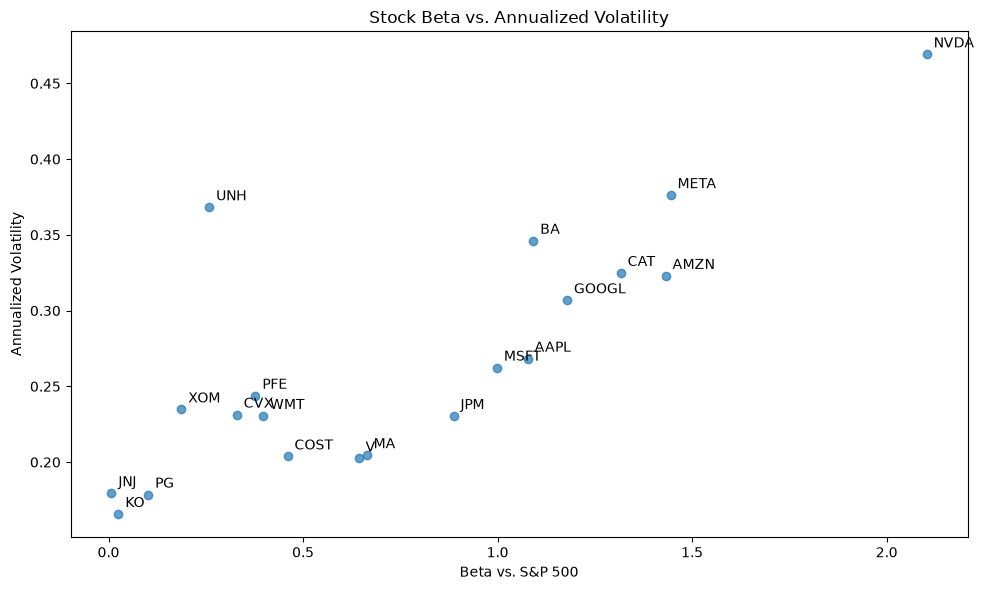

In [284]:
#Plotting Volatility and Beta 
plt.figure(figsize=(10, 6))

plt.scatter(
    risk_summary["Beta"],
    risk_summary["Annualized Volatility"],
    alpha=0.7
)

for ticker in risk_summary.index:
    plt.annotate(
        ticker,
        (
            risk_summary.loc[ticker, "Beta"],
            risk_summary.loc[ticker, "Annualized Volatility"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("Stock Beta vs. Annualized Volatility")
plt.xlabel("Beta vs. S&P 500")
plt.ylabel("Annualized Volatility")
plt.tight_layout()

plt.show()

In [285]:
# Quantifying Beta and Vol. relationship
beta_volatility_correlation = risk_summary["Beta"].corr(
    risk_summary["Annualized Volatility"]
)

print(
    f"Correlation between Beta and annualized volatility: "
    f"{beta_volatility_correlation:.3f}"
)

Correlation between Beta and annualized volatility: 0.799


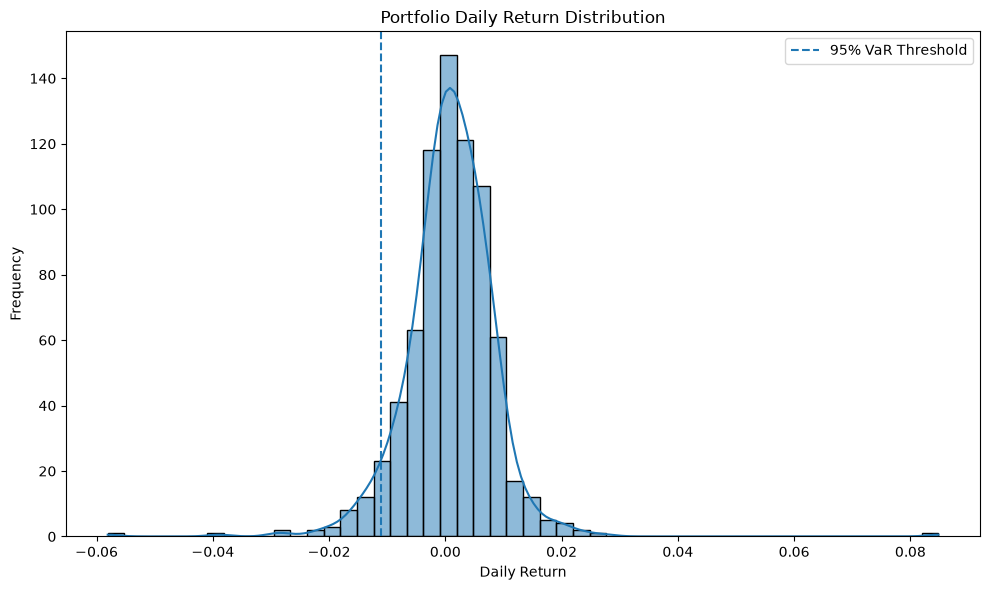

In [286]:
#visualizing frequency against daily returns

plt.figure(figsize=(10, 6))

sns.histplot(
    portfolio_returns,
    bins=50,
    kde=True
)

plt.axvline(
    -historical_var_95,
    linestyle="--",
    label="95% VaR Threshold"
)

plt.title("Portfolio Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()

plt.show()

In [287]:
# find the historical outliars
var_breaches = portfolio_returns <= -historical_var_95

print(f"VaR threshold: {-historical_var_95:.2%}")
print(f"VaR breaches: {var_breaches.sum()}")
print(f"Total observations: {len(portfolio_returns)}")
print(f"Observed breach rate: {var_breaches.mean():.2%}")

VaR threshold: -1.11%
VaR breaches: 38
Total observations: 752
Observed breach rate: 5.05%


In [288]:
#success over 3 years for both 
portfolio_cumulative = (1 + portfolio_returns).cumprod() - 1
market_cumulative = (1 + market_returns).cumprod() - 1

print(f"Portfolio cumulative return: {portfolio_cumulative.iloc[-1]:.2%}")
print(f"S&P 500 cumulative return: {market_cumulative.iloc[-1]:.2%}")

Portfolio cumulative return: 87.44%
S&P 500 cumulative return: 72.15%


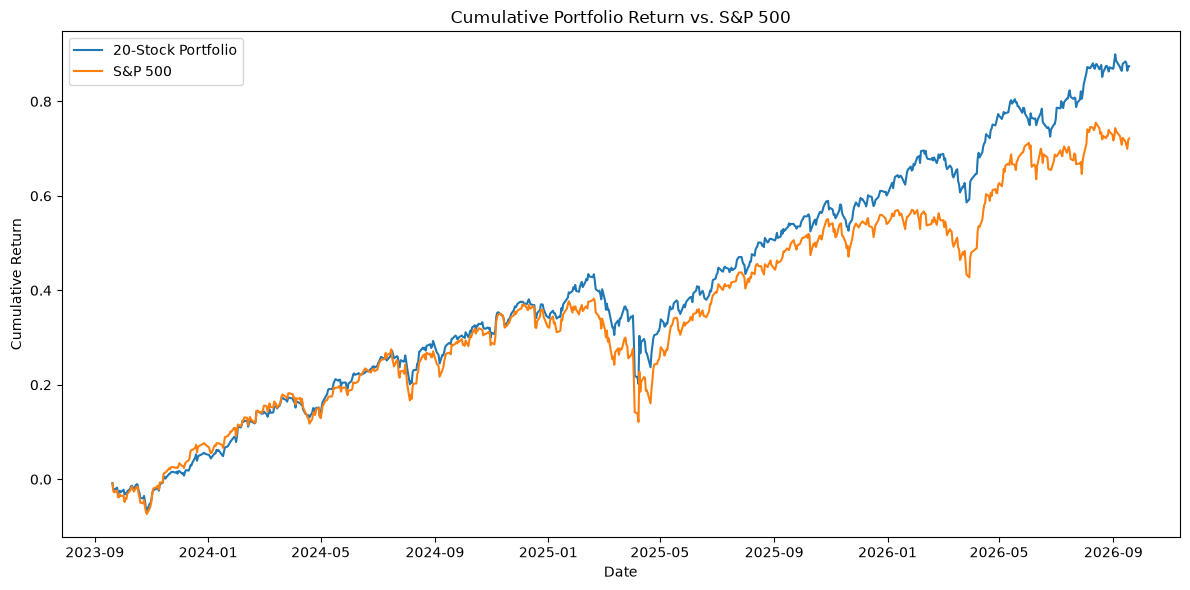

In [289]:
#growth of portfolio vs S&P
plt.figure(figsize=(12, 6))

plt.plot(
    portfolio_cumulative.index,
    portfolio_cumulative,
    label="20-Stock Portfolio"
)

plt.plot(
    market_cumulative.index,
    market_cumulative,
    label="S&P 500"
)

plt.title("Cumulative Portfolio Return vs. S&P 500")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.tight_layout()

plt.show()

In [290]:
# calculate drawdown
portfolio_value = (1 + portfolio_returns).cumprod()

running_peak = portfolio_value.cummax()

drawdown = (portfolio_value - running_peak) / running_peak

max_drawdown = drawdown.min()
max_drawdown_date = drawdown.idxmin()

print(f"Maximum drawdown: {max_drawdown:.2%}")
print(f"Maximum drawdown date: {max_drawdown_date.date()}")

Maximum drawdown: -16.23%
Maximum drawdown date: 2025-04-08


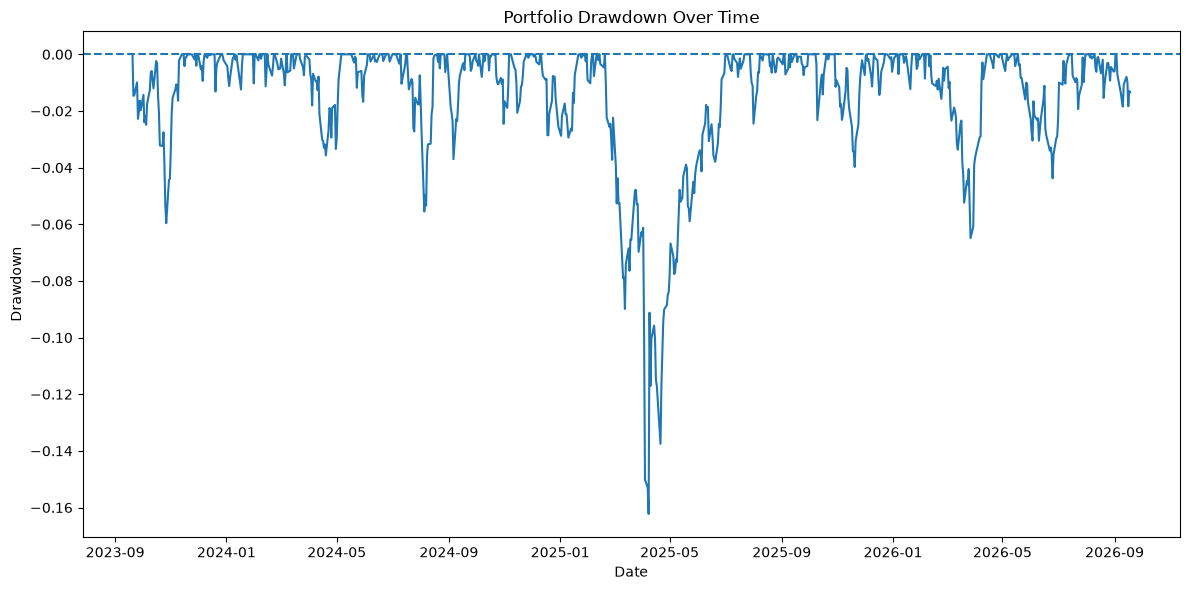

In [291]:
# now im gonna graph the drawdonw
plt.figure(figsize=(12, 6))

plt.plot(
    drawdown.index,
    drawdown
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Portfolio Drawdown Over Time")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.tight_layout()

plt.show()

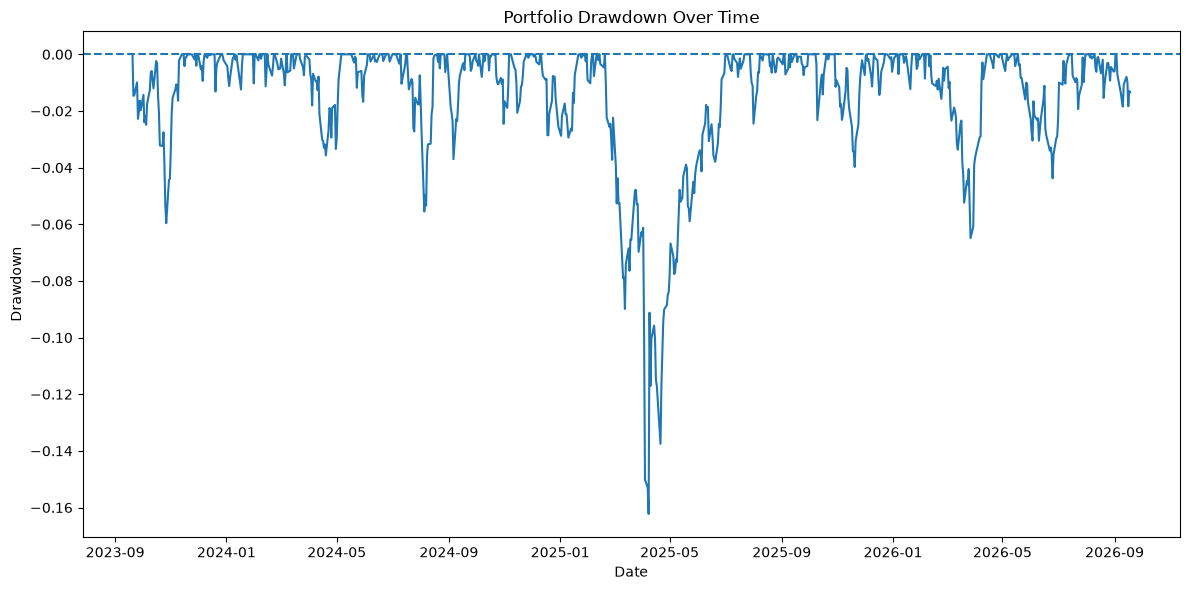

In [292]:
# now im gonna graph the drawdonw
plt.figure(figsize=(12, 6))

plt.plot(
    drawdown.index,
    drawdown
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Portfolio Drawdown Over Time")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.tight_layout()

plt.show()

In [293]:
# Sharpe Ratio

risk_free_rate = 0.04

start_date = portfolio_returns.index.min()
end_date = portfolio_returns.index.max()

years = (end_date - start_date).days / 365.25
annualized_return_exact = (1 + cumulative_portfolio_return) ** (1 / years) - 1

print(f"Annualized return using exact sample period: {annualized_return_exact:.2%}")

daily_risk_free_rate = (1 + risk_free_rate) ** (1 / 252) - 1

excess_returns = portfolio_returns - daily_risk_free_rate

sharpe_ratio_exact = (
    excess_returns.mean() / excess_returns.std()
) * np.sqrt(252)

print(f"Daily risk-free rate: {daily_risk_free_rate:.6%}")
print(f"Annualized Sharpe ratio: {sharpe_ratio_exact:.2f}")

Annualized return using exact sample period: 23.34%
Daily risk-free rate: 0.015565%
Annualized Sharpe ratio: 1.43


In [294]:
var_threshold = np.percentile(portfolio_returns, 5)

expected_shortfall_95 = -portfolio_returns[
    portfolio_returns <= var_threshold
].mean()

print(f"95% VaR: {historical_var_95:.2%}")
print(f"95% Expected Shortfall: {expected_shortfall_95:.2%}")

95% VaR: 1.11%
95% Expected Shortfall: 1.73%


In [295]:
#weight of each stock's  risk contribution

covariance_matrix = returns[tickers].cov() * 252

portfolio_variance = np.dot(
    weights,
    np.dot(covariance_matrix, weights)
)

marginal_contribution = np.dot(covariance_matrix, weights)

component_contribution = weights * marginal_contribution

risk_contribution = component_contribution / portfolio_variance

risk_contribution = pd.Series(
    risk_contribution,
    index=tickers
).sort_values(ascending=False)

print(risk_contribution)
print(f"\nTotal risk contribution: {risk_contribution.sum():.2%}")

NVDA     0.095893
META     0.088779
AMZN     0.084776
BA       0.072293
GOOGL    0.067424
CAT      0.065860
AAPL     0.064167
JPM      0.055028
MSFT     0.055020
MA       0.051148
V        0.049046
COST     0.039699
WMT      0.038961
UNH      0.035414
PFE      0.033847
CVX      0.032869
XOM      0.024970
PG       0.018210
JNJ      0.013368
KO       0.013228
dtype: float64

Total risk contribution: 100.00%


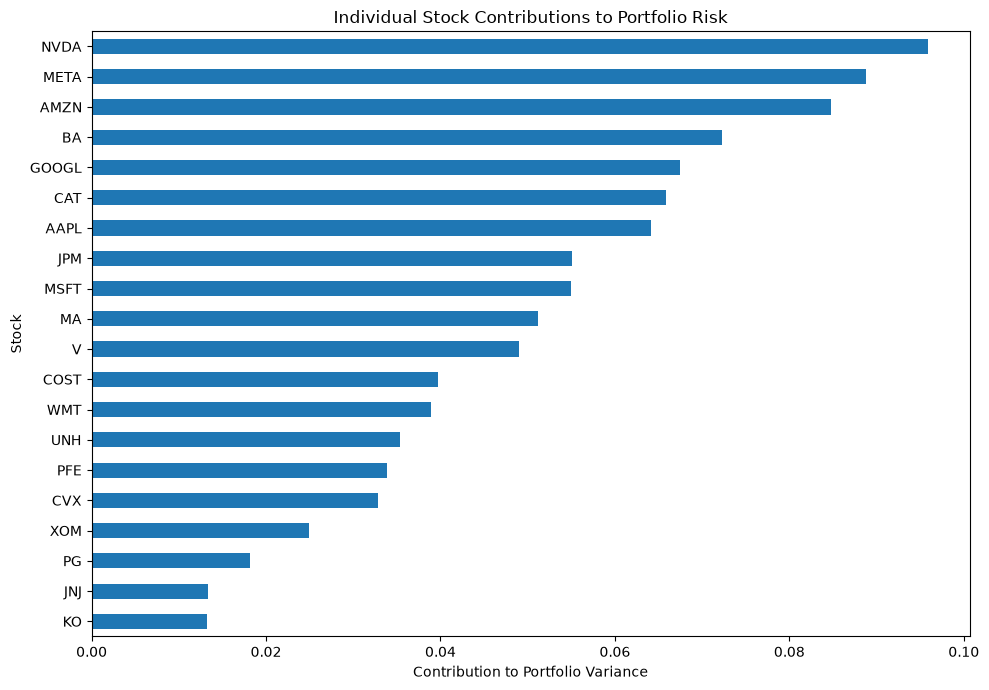

In [296]:
# risk distrubution - graphed

risk_contribution.sort_values().plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("Individual Stock Contributions to Portfolio Risk")
plt.xlabel("Contribution to Portfolio Variance")
plt.ylabel("Stock")
plt.tight_layout()

plt.show()

In [297]:
# Stock-Level Geometric Annualized Returns

stock_cumulative_returns = (1 + returns[tickers]).prod() - 1

annualized_stock_returns_exact = (
    (1 + stock_cumulative_returns) ** (1 / years)
) - 1

print("Stock-level geometric annualized returns:")
print(annualized_stock_returns_exact.sort_values(ascending=False).round(4))

Stock-level geometric annualized returns:
Ticker
NVDA     0.7253
CAT      0.4458
GOOGL    0.3680
JPM      0.3589
META     0.3014
WMT      0.2651
AAPL     0.2395
AMZN     0.2265
JNJ      0.2197
KO       0.1824
COST     0.1822
V        0.1561
MSFT     0.1545
XOM      0.1538
CVX      0.1242
MA       0.1166
PG       0.0102
PFE     -0.0050
BA      -0.0103
UNH     -0.0584
dtype: float64


In [298]:
#Update dashboard with geometric annualized returns - attempt 2

risk_dashboard["Annualized Return"] = pd.concat([
    annualized_stock_returns_exact,
    pd.Series({"PORTFOLIO": annualized_return_exact})
])

# Reorder columns for readability
risk_dashboard = risk_dashboard[
    [
        "Beta",
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio",
        "S&P 500 Correlation",
        "Max Drawdown",
        "95% VaR",
        "95% Expected Shortfall",
        "Risk Contribution",
        "Cumulative Return"
    ]
]

display(
    risk_dashboard.style
    .format({
        "Beta": "{:.2f}",
        "Annualized Return": "{:.2%}",
        "Annualized Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.2f}",
        "S&P 500 Correlation": "{:.3f}",
        "Max Drawdown": "{:.2%}",
        "95% VaR": "{:.2%}",
        "95% Expected Shortfall": "{:.2%}",
        "Risk Contribution": "{:.2%}",
        "Cumulative Return": "{:.2%}"
    })
)

,Beta,Annualized Return,Annualized Volatility,Sharpe Ratio,S&P 500 Correlation,Max Drawdown,95% VaR,95% Expected Shortfall,Risk Contribution,Cumulative Return
NVDA,2.10,72.53%,46.89%,1.31,0.675,-36.88%,4.23%,6.27%,9.59%,406.90%
META,1.44,30.14%,37.60%,0.79,0.578,-34.15%,3.24%,5.08%,8.87%,122.05%
AMZN,1.43,22.65%,32.29%,0.66,0.667,-30.88%,2.89%,4.27%,8.48%,81.66%
BA,1.09,-1.03%,34.59%,0.03,0.475,-48.31%,3.20%,4.76%,7.23%,-3.21%
GOOGL,1.18,36.80%,30.66%,1.05,0.578,-29.81%,2.65%,4.26%,6.74%,154.96%
CAT,1.32,44.58%,32.47%,1.17,0.610,-34.05%,3.08%,4.50%,6.59%,200.23%
AAPL,1.08,23.95%,26.81%,0.80,0.604,-33.36%,2.50%,3.82%,6.41%,91.57%
JPM,0.89,35.89%,23.03%,1.28,0.579,-24.42%,2.05%,3.51%,5.50%,149.81%
MSFT,1.00,15.45%,26.22%,0.53,0.573,-34.50%,2.45%,3.52%,5.50%,53.54%
MA,0.66,11.66%,20.45%,0.44,0.488,-20.91%,1.92%,3.06%,5.12%,38.18%


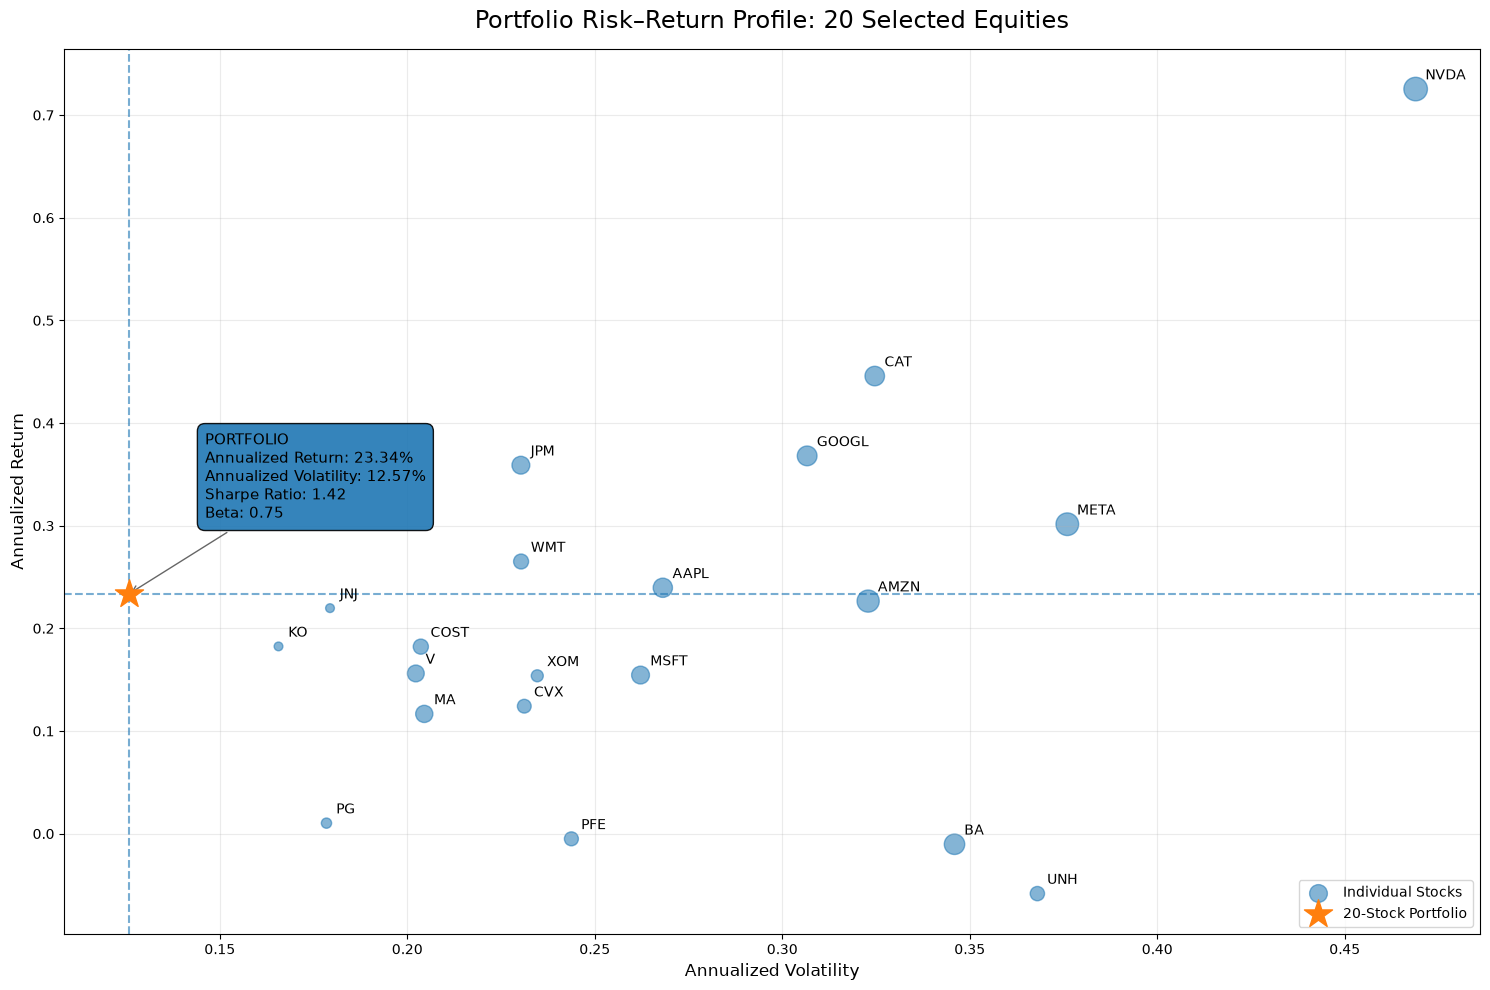

In [299]:
# Final Portfolio Risk–Return Dashboard - attempt 3

plt.figure(figsize=(15, 10))

# Scale bubble size by portfolio risk contribution
bubble_sizes = risk_dashboard.loc[tickers, "Risk Contribution"] * 3000

# Plot individual stocks
plt.scatter(
    risk_dashboard.loc[tickers, "Annualized Volatility"],
    risk_dashboard.loc[tickers, "Annualized Return"],
    s=bubble_sizes,
    alpha=0.55,
    label="Individual Stocks"
)

# Label stocks
for ticker in tickers:
    x = risk_dashboard.loc[ticker, "Annualized Volatility"]
    y = risk_dashboard.loc[ticker, "Annualized Return"]

    plt.annotate(
        ticker,
        (x, y),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=10
    )

# Portfolio values
portfolio_x = risk_dashboard.loc["PORTFOLIO", "Annualized Volatility"]
portfolio_y = risk_dashboard.loc["PORTFOLIO", "Annualized Return"]
portfolio_sharpe = risk_dashboard.loc["PORTFOLIO", "Sharpe Ratio"]
portfolio_beta = risk_dashboard.loc["PORTFOLIO", "Beta"]

# Plot portfolio
plt.scatter(
    portfolio_x,
    portfolio_y,
    s=450,
    marker="*",
    label="20-Stock Portfolio",
    zorder=5
)

# Portfolio reference lines
plt.axvline(
    portfolio_x,
    linestyle="--",
    alpha=0.6
)

plt.axhline(
    portfolio_y,
    linestyle="--",
    alpha=0.6
)

# Portfolio annotation box
# Portfolio annotation box
portfolio_text = (
    "PORTFOLIO\n"
    f"Annualized Return: {portfolio_y:.2%}\n"
    f"Annualized Volatility: {portfolio_x:.2%}\n"
    f"Sharpe Ratio: {portfolio_sharpe:.2f}\n"
    f"Beta: {portfolio_beta:.2f}"
)

plt.annotate(
    portfolio_text,
    xy=(portfolio_x, portfolio_y),
    xytext=(55, 55),       # moved up and right
    textcoords="offset points",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5", alpha=0.9),
    arrowprops=dict(arrowstyle="->", alpha=0.6)

)

# Titles and labels
plt.title(
    "Portfolio Risk–Return Profile: 20 Selected Equities",
    fontsize=17,
    pad=15
)

plt.xlabel(
    "Annualized Volatility",
    fontsize=12
)

plt.ylabel(
    "Annualized Return",
    fontsize=12
)

plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()

# Save high-resolution figure
plt.savefig(
    "../figures/risk_return_risk_contribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [300]:
portfolio_beta = robust_model.params[benchmark]

print(f"Portfolio Beta: {portfolio_beta:.4f}")

Portfolio Beta: 0.7490


## Key Findings

### Portfolio Performance

The equal-weight portfolio generated an **87.05% cumulative return** over the approximately three-year sample period, corresponding to a **23.23% geometrically annualized return**.

### Risk and Risk-Adjusted Performance

The portfolio's **annualized volatility was 12.57%**, substantially below the volatility of each individual stock in the selected universe. This reflects the diversification benefit produced by combining assets with imperfectly correlated returns.

Using a **4% annual risk-free rate**, the portfolio produced a **Sharpe ratio of 1.42**, indicating positive risk-adjusted performance over the sample period under the stated assumptions.

### Downside Risk

Historical downside measures indicate a **95% daily Value at Risk of 1.10%** and a **95% Expected Shortfall of 1.73%**. The historical VaR threshold was exceeded on approximately 5% of trading days, consistent with the expected frequency for a 95% historical VaR estimate.

The portfolio's **maximum drawdown was 16.23%**, with the largest drawdown occurring during the spring 2025 period.

### Market Sensitivity

The portfolio had a **Beta of 0.75** relative to the S&P 500 and a daily return correlation of **0.896** with the benchmark. The regression model produced an R-squared of approximately **0.80**, indicating that movements in the S&P 500 explained a substantial portion of the portfolio's daily return variation during the sample period.

### Individual Stock Risk

Risk contribution analysis showed that equal capital allocations did not result in equal contributions to portfolio risk. Stocks with higher volatility and stronger covariance with the rest of the portfolio generally contributed more to total portfolio variance.

Across the 20-stock universe, individual stock Beta and annualized volatility exhibited a **strong positive correlation (r = 0.799)**. This relationship describes the observed association in the sample and does not imply causation.

### Volatility Over Time

Thirty-day rolling volatility varied substantially throughout the sample period. Portfolio volatility reached a maximum of approximately **37.79% annualized**, demonstrating that portfolio-level risk was not constant over time.

## Limitations & Assumptions

This analysis is intended as a historical risk and performance study rather than a forecast of future market behavior.

### Portfolio Construction

The portfolio is an equal-weight portfolio with a 5% allocation to each of the 20 selected equities. Portfolio returns are calculated using fixed daily weights, which effectively represents daily rebalancing to the target weights.

No transaction costs, taxes, bid-ask spreads, or other trading frictions are included.

### Stock Selection

The analysis uses a selected universe of 20 large-cap U.S. equities rather than the complete S&P 500. Results therefore describe the selected portfolio and should not be interpreted as representative of the entire U.S. equity market.

### Historical Data

The analysis uses approximately three years of historical daily price data. Historical relationships, volatility levels, correlations, and risk measures may change over time and are not guaranteed to persist.

### Value at Risk & Expected Shortfall

VaR and Expected Shortfall are calculated using historical simulation and therefore depend on the observed return distribution during the sample period. These measures do not provide a guarantee of future maximum losses.

The 95% VaR estimate represents the historical return threshold associated with the worst 5% of observations. Expected Shortfall represents the average loss among observations beyond that threshold.

### Sharpe Ratio

Sharpe ratio calculations assume a constant **4% annual risk-free rate** throughout the sample period. This is a simplifying assumption used for consistency rather than a reconstruction of the actual daily risk-free rate.

### Regression & Beta

Beta is estimated using ordinary least squares regression of daily returns against the S&P 500. HC3 heteroskedasticity-robust standard errors are used for regression inference.

Financial return data can exhibit non-normality and changing volatility over time. Therefore, regression results should be interpreted as statistical estimates for the sample period rather than permanent relationships.

### Portfolio Performance

The portfolio's historical return should not be interpreted as a prediction of future performance. The analysis does not account for investment constraints, portfolio turnover, taxes, transaction costs, or survivorship/selection effects associated with the chosen stock universe.

In [301]:
#Export Key Project Figures - Wrapping things up

import os

figures_path = "../figures"
os.makedirs(figures_path, exist_ok=True)


# 1. Rolling Volatility
plt.figure(figsize=(12, 6))

plt.plot(
    rolling_volatility.index,
    rolling_volatility,
    label="30-Day Rolling Volatility"
)

plt.axhline(
    annualized_volatility,
    linestyle="--",
    label="Full-Sample Volatility"
)

plt.title("30-Day Rolling Portfolio Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.tight_layout()

plt.savefig(
    f"{figures_path}/rolling_volatility.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# 2. Portfolio vs. S&P 500 Cumulative Returns
plt.figure(figsize=(12, 6))

plt.plot(
    portfolio_cumulative.index,
    portfolio_cumulative,
    label="20-Stock Portfolio"
)

plt.plot(
    market_cumulative.index,
    market_cumulative,
    label="S&P 500"
)

plt.title("Cumulative Portfolio Return vs. S&P 500")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.tight_layout()

plt.savefig(
    f"{figures_path}/portfolio_vs_sp500.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# 3. Portfolio Drawdown
plt.figure(figsize=(12, 6))

plt.plot(
    drawdown.index,
    drawdown
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Portfolio Drawdown Over Time")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.tight_layout()

plt.savefig(
    f"{figures_path}/portfolio_drawdown.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# 4. Daily Return Distribution + VaR
plt.figure(figsize=(10, 6))

sns.histplot(
    portfolio_returns,
    bins=50,
    kde=True
)

plt.axvline(
    -historical_var_95,
    linestyle="--",
    label="95% VaR Threshold"
)

plt.title("Portfolio Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()

plt.savefig(
    f"{figures_path}/return_distribution_var.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# 5. Beta vs. Annualized Volatility
plt.figure(figsize=(10, 6))

plt.scatter(
    risk_summary["Beta"],
    risk_summary["Annualized Volatility"],
    alpha=0.7
)

for ticker in risk_summary.index:
    plt.annotate(
        ticker,
        (
            risk_summary.loc[ticker, "Beta"],
            risk_summary.loc[ticker, "Annualized Volatility"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("Stock Beta vs. Annualized Volatility")
plt.xlabel("Beta vs. S&P 500")
plt.ylabel("Annualized Volatility")
plt.tight_layout()

plt.savefig(
    f"{figures_path}/beta_vs_volatility.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# 6. Portfolio Risk Contribution
plt.figure(figsize=(10, 7))

risk_contribution.sort_values().plot(
    kind="barh"
)

plt.title("Individual Stock Contributions to Portfolio Risk")
plt.xlabel("Contribution to Portfolio Variance")
plt.ylabel("Stock")
plt.tight_layout()

plt.savefig(
    f"{figures_path}/risk_contribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


print("Figures exported successfully!")
print("\nSaved files:")

for filename in sorted(os.listdir(figures_path)):
    print(f"  ✓ {filename}")

Figures exported successfully!

Saved files:
  ✓ beta_vs_volatility.png
  ✓ portfolio_drawdown.png
  ✓ portfolio_vs_sp500.png
  ✓ return_distribution_var.png
  ✓ risk_contribution.png
  ✓ risk_return_risk_contribution.png
  ✓ rolling_volatility.png
